In [1]:
import time
import importlib
import matplotlib.pyplot as plt

import torch

import torch
from torch import nn
import torch.nn.functional as F
from torch import pi
import torchvision.transforms as transforms

from DIC_Net import Network, funcs, speckle_dataset
from DIC_Net import dic_tools as dic
dic.load_interp_kernels()

# Générations du dataset

Dans les méthodes proposées dans les articles `Deep DIC` et `DIC-Net`, des images initiales, simulées et/ou réelles, sont utilisées pour générer des paires d'images. L'approche est intéressante, mais peut être encore améliorée.

Pour ce projet, à chaque époch, *N0* images initiales sont générées avant l'extraction des mini-batch.
Puis, en fonction de l'index demandée pour chaque image du mini-batch, ([0 - 16*N0] de manière aléatoire), une paire d'image est générée avec différentes variations induisant une décorrelation totale ou partielle:
- netagif : image = 1. - image ($\times 2$)
- miroir horizontal : image = image[:, ::-1] ($\times 2$)
- rotation 90° : image = image.rot90([-1, 0, 1, 2]) ($\times 4$)

Ce protocole permet d'obtenir plus 16*N0 images plus rapidement qu'en calculant directement des images complètes de speckles.

## Méthode d'interpolation

Pour les méthodes de `corrélation d'images numériques`, il est largement admis que la `méthode` d'`interpolation` impacte fortement les `résultats`.


La génération du dataset reposant sur l'interpolation d'une `image initiale` afin de générer une `image` de `référence` et une `image déformée`, il semble logique que la méthode d'interpolation utilisée influe sur les `résultats du réseau de neurones` à construire/entrainer.

Généralement, l'interpolation est réalisée à partir de `noyaux pre-calculés` en optimisant la `réponse fréquentielle` (voir *Image Correlation for Shape, Motion
and Deformation Measurements*, M. Sutton, J.-J. Orteu et H. W. Schreier). Ils sont ici calculés à partir de la `réponse spatiale` désirée, *i.e.* une `gaussienne`, dont la `réponse fréquentielle` est `connue`.

À noter: 
- les variations d'amplitudes ne sont pas génantes puisque les deux images, `référence` et `déformée`, sont toutes les deux interpolées ; de plus pour des plateaux, le niveaux restent similaires.
- les méthodes d'interpolation `bilinear` et `bicubic` resposent sur un principe d'estimation polynomiale, donc n'induisent pas de variation de niveaux même pour une impulsion

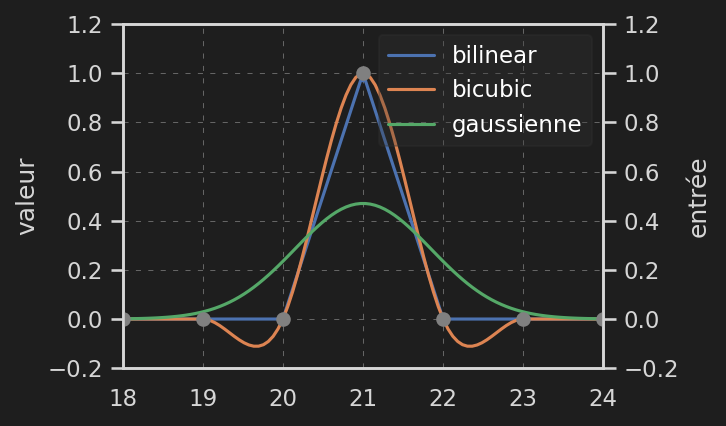

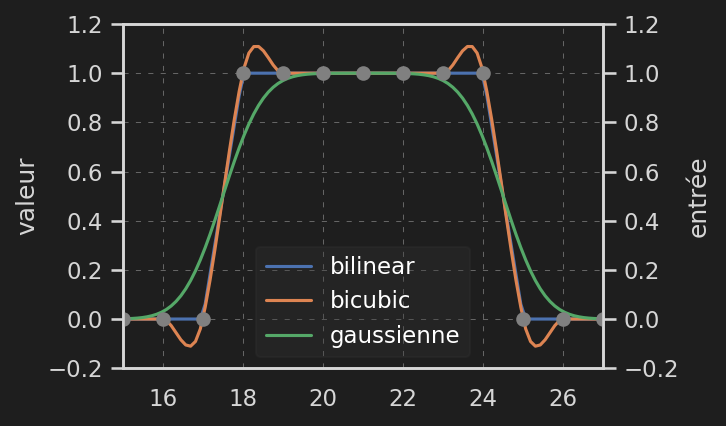

In [44]:
def plot_interp_IRs_0(x, u_interp, y_lin, y_cub, y_gauss):
    fig, ax = plt.subplots(figsize=(5,3))
    ax2 = ax.twinx()
    ax2.grid(visible=False)
    ax2.plot(x, 'o', color='0.5')
    ax2.set_ylabel('entrée')
    ax.plot(u_interp, y_lin, label='bilinear')
    ax.plot(u_interp, y_cub, label='bicubic')
    ax.plot(u_interp, y_gauss, label='gaussienne')
    ax.set_xlim(u_interp[[0, -1]])
    ax.legend()
    ax.set_ylabel('x (pixels)')
    ax.set_ylabel('valeur')

    ylim = [-0.2, 1.2]
    ax.set_ylim(ylim)
    ax2.set_ylim(ylim)
    fig.tight_layout()

def plot_interp_IRs():
    ic = 21
    x = torch.zeros((2*ic+1,)*2, dtype=torch.float)
    x[ic, ic] = 1.
    x[:, ic] = 1.

    u_interp = torch.linspace(ic-3, ic+3, 100)
    v_interp = torch.tensor([ic], dtype=torch.float)
    xi, yi = torch.meshgrid(u_interp, v_interp, indexing='xy')
    xyi = torch.cat((xi, yi)).T

    xyi_normed = (xyi / torch.tensor([x.shape[-1]-1, x.shape[-2]-1]) * 2) - 1

    y_lin = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bilinear',
        align_corners=True
    ).ravel()

    y_cub = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bicubic',
        align_corners=True
    ).ravel()

    y_gauss = dic.interp_img(x, xi.ravel(), yi.ravel())

    plot_interp_IRs_0(x[ic], u_interp, y_lin, y_cub, y_gauss)


    n = 3
    # plateau
    u_interp = torch.linspace(ic-n-3, ic+n+3, 100)
    v_interp = torch.tensor([ic], dtype=torch.float)
    xi, yi = torch.meshgrid(u_interp, v_interp, indexing='xy')
    xyi = torch.cat((xi, yi)).T

    xyi_normed = (xyi / torch.tensor([x.shape[-1]-1, x.shape[-2]-1]) * 2) - 1

    x[:, ic-n:ic+n+1] = 1.

    y_lin = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bilinear',
        align_corners=True
    ).ravel()

    y_cub = F.grid_sample(
        x[None, None],
        xyi_normed[None, None],
        mode='bicubic',
        align_corners=True
    ).ravel()

    y_gauss = dic.interp_img(x, xi.ravel(), yi.ravel())

    plot_interp_IRs_0(x[ic], u_interp, y_lin, y_cub, y_gauss)

plot_interp_IRs()

# Modélisation

In [2]:
optimizer_info = {'Adam': {}}

def scheduler_func(epoch, vmin, vmax, cste, N2):
    if epoch < N2:
        return vmin + (vmax-vmin) * cste**epoch
    
    return 0.1*(vmin + (vmax-vmin) * cste**(epoch-N2))


class LossCalculator():
    def __init__(self, mode):
        self.MSEloss = nn.MSELoss()
        if mode == 'displacement':
            self.weights = torch.tensor(
                [10.],
                dtype=torch.float,
                device=Network.DEVICE
            ).reshape(1, 1, 1, 1)
        else:
            self.weights = torch.tensor(
                [100.],
                dtype=torch.float,
                device=Network.DEVICE
            ).reshape(1, 1, 1, 1)

    def __call__(self, pred, target):
        return self.MSEloss(pred * self.weights, target * self.weights)

def plot_lr(optimizer_info, scheduler_info, epochs):
    fig, ax = plt.subplots(figsize=(5,3))
    ax.semilogy(Network.get_scheduler_curve(optimizer_info, scheduler_info, epochs))
    ax.set_xlabel('epoch')
    ax.set_ylabel('learning rate')
    ax.yaxis.grid(which='minor')
    fig.tight_layout()

def plot_map_test_0(trainer, datasets):
    trainer.model.eval()

    for case in [0, 1]:
        X, y, resample_infos = datasets['test'].__getitem__(0, case)
        ur, vr = datasets['test'].uvr
        ur, vr = ur.to('cuda'), vr.to('cuda')

        with torch.no_grad():
            pred = trainer.model(
                X[None], ur, vr, resample_infos[None].to('cuda')
            ).detach().clone().to('cpu')[0]
            y = y.detach().clone().to('cpu')

        # print('y:', y.shape)
        # print('pred:', pred.shape)
        # return
        k = 0
        fig, axs = plt.subplots(
            nrows=y.shape[0], ncols=2,
            figsize=(8, 3.35*y.shape[0])
            )
        fig.suptitle(f'Tailles des éléments : {[5, 9][case]} pixels')
        axs[0][0].set_title('prediction')
        axs[0][1].set_title('cible')
        
        for i in range(y.shape[0]):
            vmax = max(torch.abs(pred[i]).max(), torch.abs(y[i]).max())
            im = axs[i][0].imshow(pred[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
            im =axs[i][1].imshow(y[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
        
        for i in range(y.shape[0]):
            for j in range(2):
                axs[i][j].axis('off')
                axs[i][j].grid('off')
        fig.tight_layout()


def init_datasets(
            mode: str,
            i_case_0: int = 0,
            test_dataset: bool = True,
            batch_size: int = 16
        ):
    datasets, dataloaders = {}, {}
    scale = 4
    if test_dataset:
        N0 = 50
        datasets['test'] = speckle_dataset.SpeckleDataset(
            N0, scale, mode
        )
        dataloaders['test'] = speckle_dataset.DataLoader(
            datasets['test'], batch_size=batch_size, shuffle=True, #num_workers=10,
        )
    else:
        datasets['test'] = None
        dataloaders['test'] = None

    N0 = 200
    datasets['train'] = speckle_dataset.SpeckleDataset(
        N0, scale, mode
    )
    dataloaders['train'] = speckle_dataset.DataLoader(
        datasets['train'], batch_size=batch_size, shuffle=True, num_workers=10,
    )
    return datasets, dataloaders


def init_model_and_trainer(
            dataloaders, mode, optimizer_info, scheduler_info,
            test_loop: bool,
            modif_conv1: dict = None,
            n_channels_0: int = None,
            upsample: str = 'bilinear',
            weight_scaling: bool = False,
            norm: dict = None,
            block: dict = None,
        ):
    in_channel = 2

    if mode == 'displacement':
        out_channel = 2
    elif mode == 'strain':
        out_channel = 4
    else:
        print(f'ERROR: mode {mode} shoud be displacement or strain')
        out_channel = 0
        return

    model = Network.DICNet(
        in_channel, out_channel,
        modif_conv1=modif_conv1,
        n_channels_0=n_channels_0,
        upsample=upsample,
        block=block,
        norm=norm,
        weight_scaling=weight_scaling
    )

    trainer = Network.NN_Trainer(
        model, dataloaders, 'mse', LossCalculator(mode),
        weight_scaling=weight_scaling,
        test_loop=test_loop
    )
    trainer.set_optimizer(optimizer_info)
    trainer.set_scheduler(scheduler_info)
    return trainer



def init_model_and_trainer_2(
            dataloaders, mode, optimizer_info, scheduler_info,
            test_loop: bool,
            modif_conv1: dict = None,
            upsample: str = 'bilinear',
            weight_scaling: bool = False,
            norm: dict = None,
        ):
    in_channel = 2

    if mode == 'displacement':
        out_channel = 2
    elif mode == 'strain':
        out_channel = 4
    else:
        print(f'ERROR: mode {mode} shoud be displacement or strain')
        out_channel = 0
        return

    model = Network.DICNet_Dense(
        in_channel, out_channel,
        modif_conv1=modif_conv1,
        upsample=upsample,
        norm=norm,
        weight_scaling=weight_scaling
    )

    trainer = Network.NN_Trainer(
        model, dataloaders, 'mse', nn.MSELoss(),  # LossCalculator(mode),
        weight_scaling=weight_scaling,
        test_loop=test_loop
    )
    trainer.set_optimizer(optimizer_info)
    trainer.set_scheduler(scheduler_info)
    return trainer

In [3]:
i_seed = 0

In [4]:
def plot_results(results):
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    b_test = False

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    for i, name in enumerate(results):
        data = funcs.load_trainer_results(name)
        label = results[name]
        print(
            f'{label} training time:',
            funcs.chrono(data['compute time'])
        )

        lrs = data['lr']
        loss_tr = data['loss']['train']
        loss_ts = data['loss']['test']

        ax.semilogy(loss_tr, color=colors[i], label=label)
        if len(loss_ts) > 0:
            ax.plot(loss_ts, '--', color=colors[i])
            b_test = True

        ax2.semilogy(lrs, ':')

    lgd = ax.legend(loc='upper right')

    hndls = []
    ln, = ax.plot([], [], 'w-', label='train')
    hndls.append(ln)
    if b_test:
        ln, =ax.plot([], [], 'w--', label='test')
        hndls.append(ln)
    ln, = ax.plot([], [], 'w:', label='learning\nrate')
    hndls.append(ln)
    lgd2 = ax.legend(
        hndls,
        [ln.get_label() for ln in hndls],
        loc='lower left',
    )

    ax.add_artist(lgd)

    # ax2.plot(lrs, color='0.5')
    ax2.set_ylabel('learning rate')
    ax2.grid(visible=False)

    # ax.grid(visible=False)
    ax.grid(visible=True)
    ax.grid(which='minor')

    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE loss')
    fig.tight_layout()

model: Mish-GN-4-SepConv1-ResNeXt-4
DATALOADER : DISPLACEMENT
DATALOADER : DISPLACEMENT


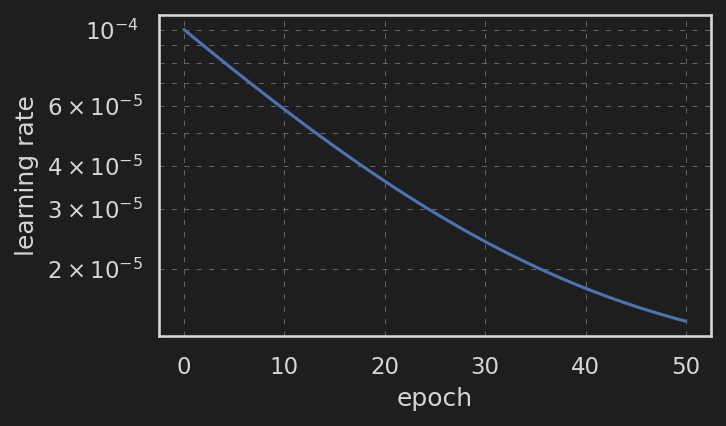

In [94]:
importlib.reload(Network)

scheduler_info = {'custom':{
    'function': scheduler_func,
    'func_args': (1e-5, 1e-4, 0.94, 150)
}}
modif_conv1 = None
weight_scaling = False
HE_init = False
mode = 'displacement'
test_loop = True
block = {'which': 'BottleNeck', 'groups':1}

epochs = 50

name = 'initial'
Network.set_activation('ReLU')
norm = None

name = 'GroupNorm-1'
norm = {'which': 'group', 'num_groups': 1, 'affine': True}

name = 'GroupNorm-4'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}

name = 'GroupNorm-8'
norm = {'which': 'group', 'num_groups': 8, 'affine': True}

name = 'GroupNorm-4-2'
norm = {'which': 'group', 'num_groups': 4, 'affine': False}

name = 'Mish-GN-4'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
test_loop = False

name = 'Mish-GN-4-SepConv1'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
modif_conv1 = {'n_subconv': 1, 'differentiator': False}
test_loop = False


name = 'Mish-GN-4-SepConv1-ResNeXt'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
modif_conv1 = {'n_subconv': 1, 'differentiator': False}
test_loop = False
# name += '-1'
# block = {'which': 'BottleNeck', 'groups':1}
name += '-4'
block = {'which': 'BottleNeck', 'groups':4}
# name += '-8'
# block = {'which': 'BottleNeck', 'groups':8}




# name = 'test8-BN-WS'

# name = 'test8-1'

# name = 'test8-1-HE'
# HE_init = True

# name = 'test8-4-2'
# norm = {
#     'which': 'group',
#     'num_groups': 4,
#     'affine': True
# }

# name = 'test8-8'
# norm = {'which': 'group', 'num_groups': 8, 'affine': True}

# name = 'test8-X-noaffine'
# norm = {'which': 'group', 'num_groups': X, 'affine': False}

# name = 'test8-instance'
# norm = {'which': 'instance', 'affine': False}


print('model:', name)
plot_lr(optimizer_info, scheduler_info, epochs)

torch.manual_seed(i_seed)

datasets, dataloaders = init_datasets(mode, 0, test_loop)
trainer = init_model_and_trainer(
    dataloaders, mode, optimizer_info, scheduler_info,
    test_loop=test_loop,
    modif_conv1=modif_conv1,
    weight_scaling=weight_scaling,
    norm=norm,
    block=block
)

if HE_init:
    trainer.model.HE_init()

In [96]:
if True:
    torch.manual_seed(i_seed)
    trainer.train_network(epochs)
    trainer.save_results(name)

Epoch 50 / 50, lr 0.000014340
train MSE: 0.826, 0.847, 0.850, 0.841, 0.846
test MSE: 
loss: 1.021155  [ 3200/ 3200]     

Done! (50 epochs in 00:48:09.93)


In [ ]:
results = {
    'initial': 'initial',
    # 'GroupNorm-1': 'group norm (1)',
    'GroupNorm-4': 'group norm (4)',
    # 'GroupNorm-8': 'group norm (8)',
    # 'GroupNorm-4-2': 'group norm 2 (4)',
}

plot_results(results)

In [ ]:
results = {
    'GroupNorm-4': 'ReLU',
    'Mish-GN-4': 'Mish',
}

plot_results(results)

Conv2d training time: 00:50:48.50
Sep Conv2d training time: 00:52:12.06


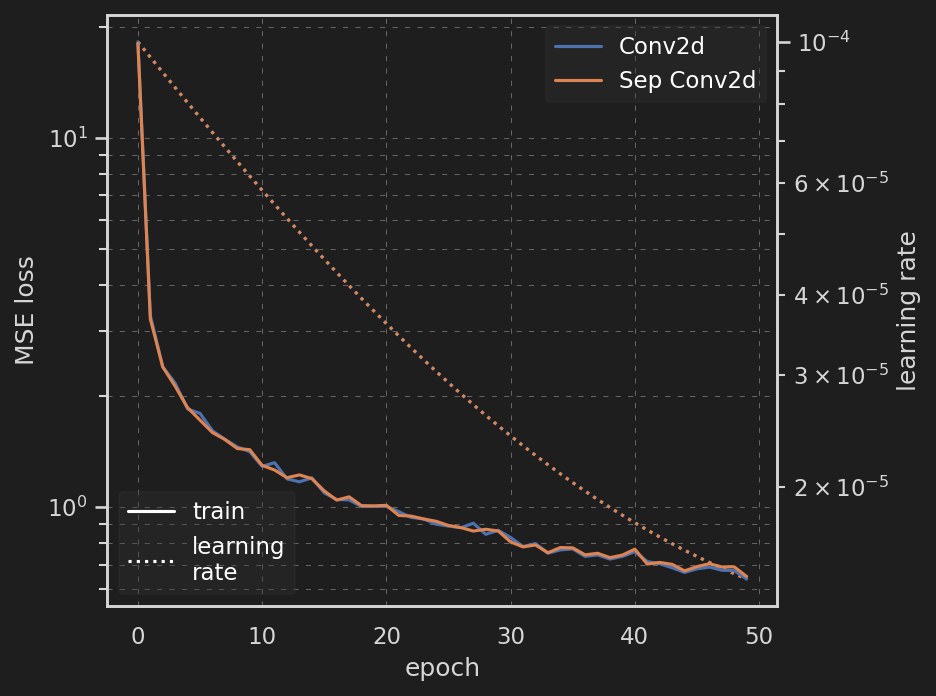

In [88]:
results = {
    'Mish-GN-4': 'Conv2d',
    'Mish-GN-4-SepConv1': 'Sep Conv2d',
}

plot_results(results)

ResNet training time: 00:52:12.06
ResNeXt training time: 00:48:09.93


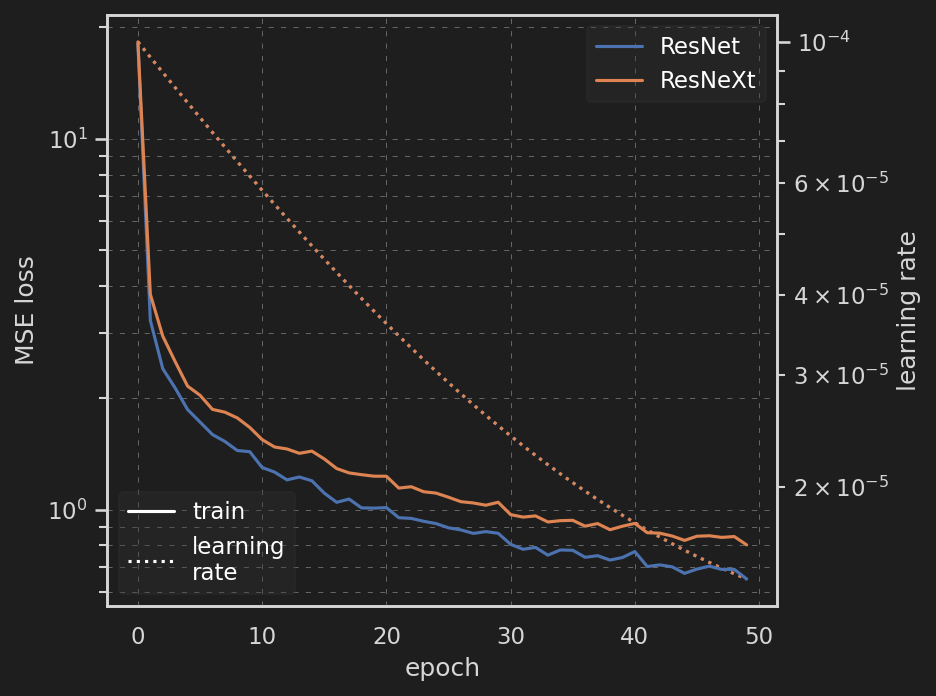

In [97]:
results = {
    'Mish-GN-4-SepConv1': 'ResNet',
    'Mish-GN-4-SepConv1-ResNeXt-4': 'ResNeXt',
}

plot_results(results)

model: DenseConv
DATALOADER : DISPLACEMENT


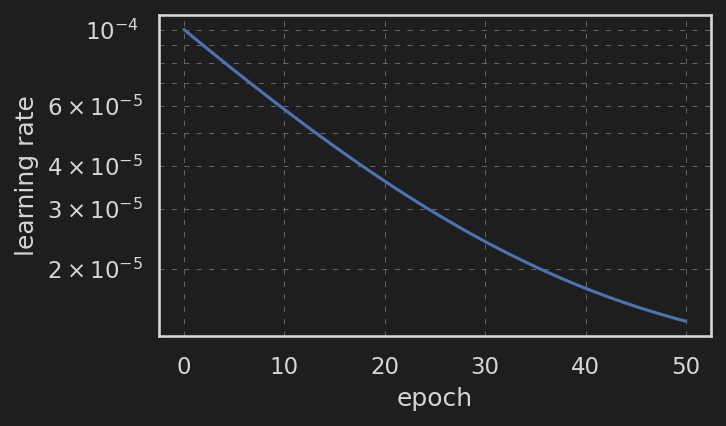

In [13]:
importlib.reload(Network)

scheduler_info = {'custom':{
    'function': scheduler_func,
    'func_args': (1e-5, 1e-4, 0.94, 150)
}}
modif_conv1 = None
weight_scaling = False
HE_init = False
mode = 'displacement'


epochs = 50

name = 'DenseConv'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
modif_conv1 = {'n_subconv': 1, 'differentiator': False}
test_loop = False

name = name + '-2'
epochs = 5

print('model:', name)
plot_lr(optimizer_info, scheduler_info, epochs)

torch.manual_seed(i_seed)

datasets, dataloaders = init_datasets(mode, 0, test_loop, 6)
trainer = init_model_and_trainer_2(
    dataloaders, mode, optimizer_info, scheduler_info,
    test_loop=test_loop,
    modif_conv1=modif_conv1,
    weight_scaling=weight_scaling,
    norm=norm,
)

if HE_init:
    trainer.model.HE_init()

In [14]:
trainer.model.conv1_x

DenseConv2dBlock(
  (0): DenseConv2dLayer(
    (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): GroupNorm(4, 64, eps=1e-05, affine=True)
    (2): Mish(inplace=True)
    (3): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): Mish(inplace=True)
    (6): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): GroupNorm(4, 16, eps=1e-05, affine=True)
    (8): Mish(inplace=True)
  )
  (1): DenseConv2dLayer(
    (0): Conv2d(80, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): GroupNorm(4, 64, eps=1e-05, affine=True)
    (2): Mish(inplace=True)
    (3): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): Mish(inplace=True)
    (6): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): GroupNorm(4, 16, eps=1e-05, affine=True)
    (8): Mish(inplace=True)
  

In [15]:
torch.manual_seed(i_seed)

In [16]:
if True:
    trainer.train_network(epochs)
    trainer.save_results(name)

Epoch 36 / 50, lr 0.000020321
train MSE: 0.545, 0.523, 0.530, 0.499, 0.540
test MSE: 


In [ ]:
results = {
    'Mish-GN-4-SepConv1': 'ResNet',
    'DenseConv': 'DenseNet',
}

plot_results(results)

In [ ]:
importlib.reload(Network)

scheduler_info = {'custom':{
    'function': scheduler_func,
    'func_args': (1e-5, 1e-4, 0.94, 150)
}}
modif_conv1 = None
weight_scaling = False
HE_init = False
mode = 'displacement'


epochs = 50

name = 'DenseConv'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
modif_conv1 = {'n_subconv': 1, 'differentiator': False}
test_loop = False

name = name + '-2'
epochs = 5

print('model:', name)
plot_lr(optimizer_info, scheduler_info, epochs)

torch.manual_seed(i_seed)

datasets, dataloaders = init_datasets(mode, 0, test_loop, 6)
trainer = init_model_and_trainer_2(
    dataloaders, mode, optimizer_info, scheduler_info,
    test_loop=test_loop,
    modif_conv1=modif_conv1,
    weight_scaling=weight_scaling,
    norm=norm,
)

if HE_init:
    trainer.model.HE_init()

In [ ]:
if True:
    trainer.train_network(epochs)
    trainer.save_results(name)

In [ ]:
results = {
    'DenseConv': 'DenseNet',
    'DenseConv-2': 'DenseNet - 2',
}

plot_results(results)

In [ ]:
def init_model_and_trainer_disp_strai(
            dataloaders, optimizer_info, scheduler_info,
            test_loop: bool,
            modif_conv1: dict = None,
            upsample: str = 'bilinear',
            weight_scaling: bool = False,
            norm: dict = None,
        ):

    model_disp = Network.DICNet_Dense(
        2, 2,
        modif_conv1=modif_conv1,
        upsample=upsample,
        norm=norm,
        weight_scaling=weight_scaling
    )

    model_strain = Network.DICNet_Dense(
        2, 4,
        modif_conv1=modif_conv1,
        upsample=upsample,
        norm=norm,
        weight_scaling=weight_scaling
    )

    trainer = Network.NN_Trainer(
        model_disp, model_strain, dataloaders,
        weight_scaling=weight_scaling,
        test_loop=test_loop
    )
    trainer.set_optimizer(optimizer_info)
    trainer.set_scheduler(scheduler_info)
    return trainer



In [ ]:
importlib.reload(Network)

scheduler_info = {'custom':{
    'function': scheduler_func,
    'func_args': (1e-5, 1e-4, 0.94, 150)
}}
modif_conv1 = None
weight_scaling = False
mode = 'full'

epochs = 300

name = 'final'
norm = {'which': 'group', 'num_groups': 4, 'affine': True}
Network.set_activation('Mish')
modif_conv1 = {'n_subconv': 1, 'differentiator': False}
test_loop = False

print('model:', name)
plot_lr(optimizer_info, scheduler_info, epochs)

torch.manual_seed(i_seed)

datasets, dataloaders = init_datasets(mode, 0, test_loop, 6)
trainer = init_model_and_trainer_disp_strai(
    dataloaders, optimizer_info, scheduler_info,
    test_loop=test_loop,
    modif_conv1=modif_conv1,
    weight_scaling=weight_scaling,
    norm=norm,
)